In [90]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



def load_data(file_path):
    data = pd.read_csv(file_path)
    return data


df = load_data('titanic_disaster.csv')
print("--- CÂU 1: 10 DÒNG DỮ LIỆU ĐẦU TIÊN ---")
print(df.head(10))
print("\n" + "="*50 + "\n")

--- CÂU 1: 10 DÒNG DỮ LIỆU ĐẦU TIÊN ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                       

--- CÂU 2: THỐNG KÊ DỮ LIỆU THIẾU ---
Age         177
Cabin       687
Embarked      2
dtype: int64


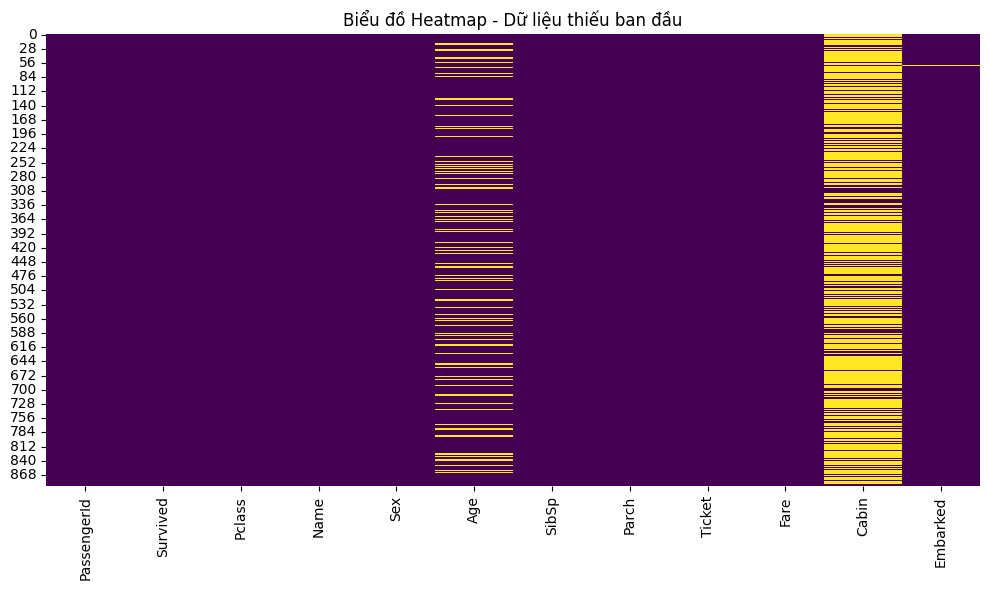

In [91]:

print("--- CÂU 2: THỐNG KÊ DỮ LIỆU THIẾU ---")
missing_summary = df.isnull().sum()
print(missing_summary[missing_summary > 0])


plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Biểu đồ Heatmap - Dữ liệu thiếu ban đầu")
plt.tight_layout()
plt.show()

In [92]:
'''
nhận xét câu 2 
Age: Thiếu mức độ vừa phải (khoảng 20% dữ liệu). Biến này rất quan trọng vì ảnh hưởng trực tiếp đến khả năng sống sót ("Ưu tiên phụ nữ và trẻ em"). Do đó cần áp dụng các kỹ thuật điền khuyết (imputation).
Cabin: Thiếu cực kỳ nghiêm trọng (lên đến hơn 77% dữ liệu trống). Điều này dễ hiểu vì thời điểm tai nạn xảy ra hỗn loạn và nhiều hành khách hạng vé thấp (hạng 3) không có số phòng cụ thể ghi nhận lại. Phương án xử lý thích hợp nhất là tạo một nhóm riêng biệt như 'Unknown'.
Embarked: Thiếu rất ít (chỉ khoảng 2 dòng trống). Với số lượng thiếu không đáng kể này, ta có thể dễ dàng điền khuyết bằng giá trị xuất hiện nhiều nhất (Mode) của cột này mà không sợ làm lệch phân phối dữ liệu.
'''

'\nnhận xét câu 2 \nAge: Thiếu mức độ vừa phải (khoảng 20% dữ liệu). Biến này rất quan trọng vì ảnh hưởng trực tiếp đến khả năng sống sót ("Ưu tiên phụ nữ và trẻ em"). Do đó cần áp dụng các kỹ thuật điền khuyết (imputation).\nCabin: Thiếu cực kỳ nghiêm trọng (lên đến hơn 77% dữ liệu trống). Điều này dễ hiểu vì thời điểm tai nạn xảy ra hỗn loạn và nhiều hành khách hạng vé thấp (hạng 3) không có số phòng cụ thể ghi nhận lại. Phương án xử lý thích hợp nhất là tạo một nhóm riêng biệt như \'Unknown\'.\nEmbarked: Thiếu rất ít (chỉ khoảng 2 dòng trống). Với số lượng thiếu không đáng kể này, ta có thể dễ dàng điền khuyết bằng giá trị xuất hiện nhiều nhất (Mode) của cột này mà không sợ làm lệch phân phối dữ liệu.\n'

In [93]:
df['firstName'] = df['Name'].str.split(',').str[0].str.strip()
df['secondName'] = df['Name'].str.split(',').str[1].str.strip()
df.drop(columns=['Name'], inplace=True)
print("--- CÂU 3: DỮ LIỆU SAU KHI TÁCH VÀ XÓA CỘT NAME ---")
print(df[['firstName', 'secondName']].head())
print("\n" + "="*50 + "\n")

--- CÂU 3: DỮ LIỆU SAU KHI TÁCH VÀ XÓA CỘT NAME ---
   firstName                                  secondName
0     Braund                             Mr. Owen Harris
1    Cumings  Mrs. John Bradley (Florence Briggs Thayer)
2  Heikkinen                                 Miss. Laina
3   Futrelle          Mrs. Jacques Heath (Lily May Peel)
4      Allen                           Mr. William Henry




In [94]:
df['Sex'] = df['Sex'].map({'male': 'M', 'female': 'F'})
print("--- CÂU 4: CỘT SEX SAU KHI RÚT GỌN KÍCH THƯỚC ---")
print(df['Sex'].value_counts())
print("\n" + "="*50 + "\n")

--- CÂU 4: CỘT SEX SAU KHI RÚT GỌN KÍCH THƯỚC ---
Sex
M    577
F    314
Name: count, dtype: int64




C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5828\3390119914.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age', data=df, palette='Set2')


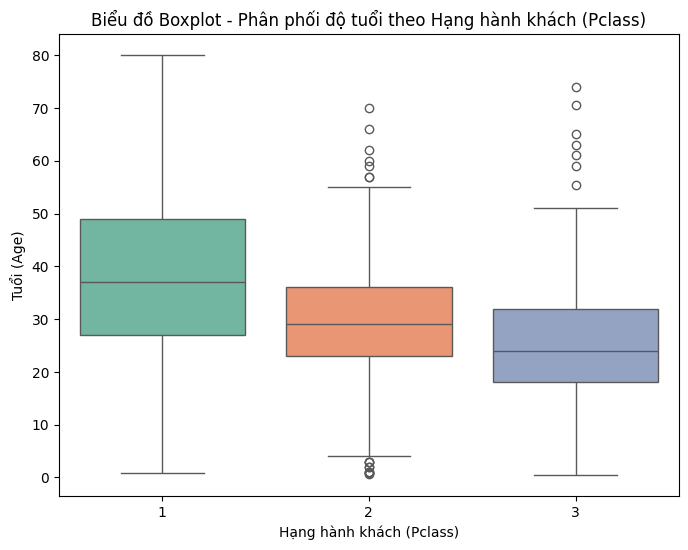

Tuổi trung bình theo từng hạng hành khách (Pclass):
Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64


In [95]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Pclass', y='Age', data=df, palette='Set2')
plt.title("Biểu đồ Boxplot - Phân phối độ tuổi theo Hạng hành khách (Pclass)")
plt.xlabel("Hạng hành khách (Pclass)")
plt.ylabel("Tuổi (Age)")
plt.show()

# Tính toán giá trị trung vị hoặc trung bình tuổi cụ thể theo từng Pclass để điền khuyết
# (Sử dụng median/mean theo từng nhóm Pclass giúp phản ánh đúng thực tế hơn)
age_means_by_pclass = df.groupby('Pclass')['Age'].mean()
print("Tuổi trung bình theo từng hạng hành khách (Pclass):")
print(age_means_by_pclass)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5828\1652506540.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5828\1652506540.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


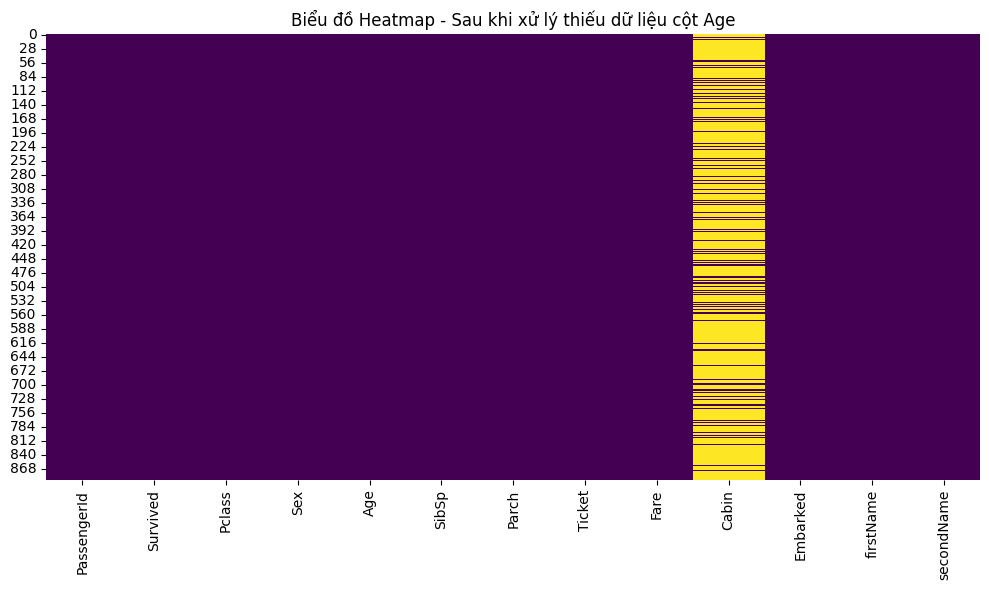

In [96]:
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]
    
    if pd.isnull(Age):
        if Pclass == 1:
            return int(age_means_by_pclass[1])
        elif Pclass == 2:
            return int(age_means_by_pclass[2])
        else:
            return int(age_means_by_pclass[3])
    else:
        return Age

df['Age'] = df[['Age', 'Pclass']].apply(impute_age, axis=1)

# Vẽ lại biểu đồ Heatmap sau khi xử lý dữ liệu thiếu cột Age
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Biểu đồ Heatmap - Sau khi xử lý thiếu dữ liệu cột Age")
plt.tight_layout()
plt.show()

In [97]:

def assign_age_group(age):

    if pd.isnull(age):
        return 'Unknown'
    

    if age <= 12:
        return 'Kid'

    elif 12 < age <= 18:
        return 'Teen'
   
    elif 18 < age <= 60:
        return 'Adult'

    else:
        return 'Older'


df['Agegroup'] = df['Age'].apply(assign_age_group)


print("--- KIỂM TRA KẾT QUẢ CÂU 6 ---")

print(df[['Age', 'Agegroup']].head(10))



--- KIỂM TRA KẾT QUẢ CÂU 6 ---
    Age Agegroup
0  22.0    Adult
1  38.0    Adult
2  26.0    Adult
3  35.0    Adult
4  35.0    Adult
5  25.0    Adult
6  54.0    Adult
7   2.0      Kid
8  27.0    Adult
9  14.0     Teen


In [105]:
df['namePrefix'] = df['secondName'].str.split('.').str[0].str.strip()

# Loại bỏ các danh xưng không phổ biến hoặc chuẩn hóa (nếu cần), ở đây giữ các nhóm chính theo đề bài
valid_prefixes = ['Mr', 'Mrs', 'Miss', 'Master']
df['namePrefix'] = df['namePrefix'].apply(lambda x: x if x in valid_prefixes else 'Others')

print(df[['secondName', 'namePrefix']].head(10))

                                   secondName namePrefix
0                             Mr. Owen Harris         Mr
1  Mrs. John Bradley (Florence Briggs Thayer)        Mrs
2                                 Miss. Laina       Miss
3          Mrs. Jacques Heath (Lily May Peel)        Mrs
4                           Mr. William Henry         Mr
5                                   Mr. James         Mr
6                               Mr. Timothy J         Mr
7                       Master. Gosta Leonard     Master
8    Mrs. Oscar W (Elisabeth Vilhelmina Berg)        Mrs
9                 Mrs. Nicholas (Adele Achem)        Mrs


In [106]:
#8
df['familySize'] = 1 + df['SibSp'] + df['Parch']
print("--- [KẾT QUẢ CÂU 8] HIỂN THỊ 15 DÒNG ĐẦU TIÊN ---")
print(df[['SibSp', 'Parch', 'familySize']].head(15))
print("\n" + "-"*40)
print("--- THỐNG KÊ SỐ LƯỢNG HÀNH KHÁCH THEO QUY MÔ GIA ĐÌNH ---")
print(df['familySize'].value_counts().sort_index())

--- [KẾT QUẢ CÂU 8] HIỂN THỊ 15 DÒNG ĐẦU TIÊN ---
    SibSp  Parch  familySize
0       1      0           2
1       1      0           2
2       0      0           1
3       1      0           2
4       0      0           1
5       0      0           1
6       0      0           1
7       3      1           5
8       0      2           3
9       1      0           2
10      1      1           3
11      0      0           1
12      0      0           1
13      1      5           7
14      0      0           1

----------------------------------------
--- THỐNG KÊ SỐ LƯỢNG HÀNH KHÁCH THEO QUY MÔ GIA ĐÌNH ---
familySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64


In [108]:

df['Alone'] = df['familySize'].apply(lambda x: 1 if x == 1 else 0)
print("--- [KẾT QUẢ CÂU 9] HIỂN THỊ ĐỐI CHIẾU 15 DÒNG ĐẦU TIÊN ---")
print(df[['familySize', 'Alone']].head(15))
print("\n" + "-"*40)


--- [KẾT QUẢ CÂU 9] HIỂN THỊ ĐỐI CHIẾU 15 DÒNG ĐẦU TIÊN ---
    familySize  Alone
0            2      0
1            2      0
2            1      1
3            2      0
4            1      1
5            1      1
6            1      1
7            5      0
8            3      0
9            2      0
10           3      0
11           1      1
12           1      1
13           7      0
14           1      1

----------------------------------------


In [110]:

df['typeCabin'] = df['Cabin'].fillna('Unknown').str[0]



print("--- [KẾT QUẢ CÂU 10] HIỂN THỊ ĐỐI CHIẾU 15 DÒNG ĐẦU TIÊN ---")

print(df[['Cabin', 'typeCabin']].head(15))

print("\n" + "-"*40)


--- [KẾT QUẢ CÂU 10] HIỂN THỊ ĐỐI CHIẾU 15 DÒNG ĐẦU TIÊN ---
   Cabin typeCabin
0    NaN         U
1    C85         C
2    NaN         U
3   C123         C
4    NaN         U
5    NaN         U
6    E46         E
7    NaN         U
8    NaN         U
9    NaN         U
10    G6         G
11  C103         C
12   NaN         U
13   NaN         U
14   NaN         U

----------------------------------------


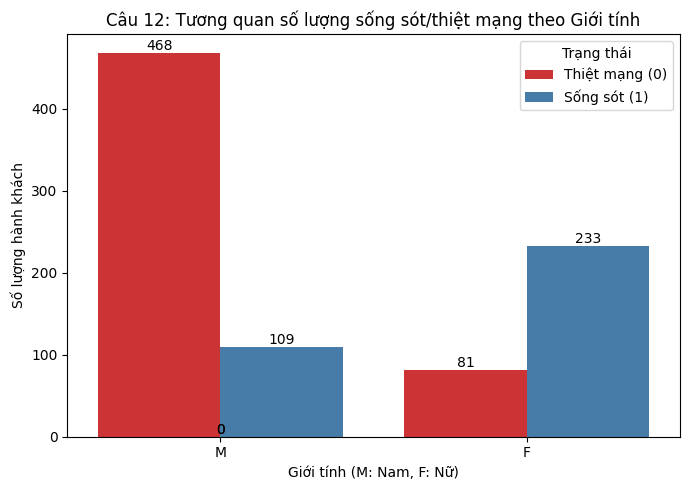

In [111]:
#12
plt.figure(figsize=(7, 5))
# Dùng Countplot với hue='Survived' để đếm rõ số lượng sống/chết theo giới tính
ax12 = sns.countplot(x='Sex', hue='Survived', data=df, palette='Set1')
plt.title('Câu 12: Tương quan số lượng sống sót/thiệt mạng theo Giới tính')
plt.xlabel('Giới tính (M: Nam, F: Nữ)')
plt.ylabel('Số lượng hành khách')
plt.legend(title='Trạng thái', labels=['Thiệt mạng (0)', 'Sống sót (1)'])
for p in ax12.patches:
    ax12.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5828\2357344886.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax13 = sns.barplot(x='Pclass', y='Survived', data=df, errorbar=None, palette='muted')


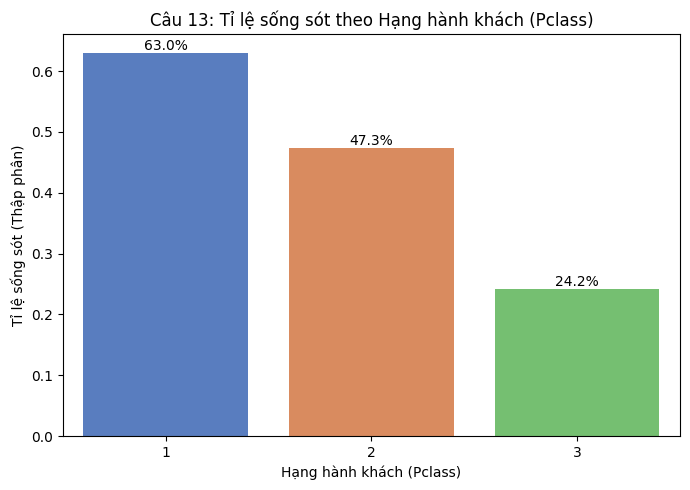

In [112]:
plt.figure(figsize=(7, 5))
# Dùng Biểu đồ cột (Barplot) hiển thị giá trị trung bình của biến Survived chính là tỉ lệ sống sót
ax13 = sns.barplot(x='Pclass', y='Survived', data=df, errorbar=None, palette='muted')
plt.title('Câu 13: Tỉ lệ sống sót theo Hạng hành khách (Pclass)')
plt.xlabel('Hạng hành khách (Pclass)')
plt.ylabel('Tỉ lệ sống sót (Thập phân)')
for p in ax13.patches:
    ax13.annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

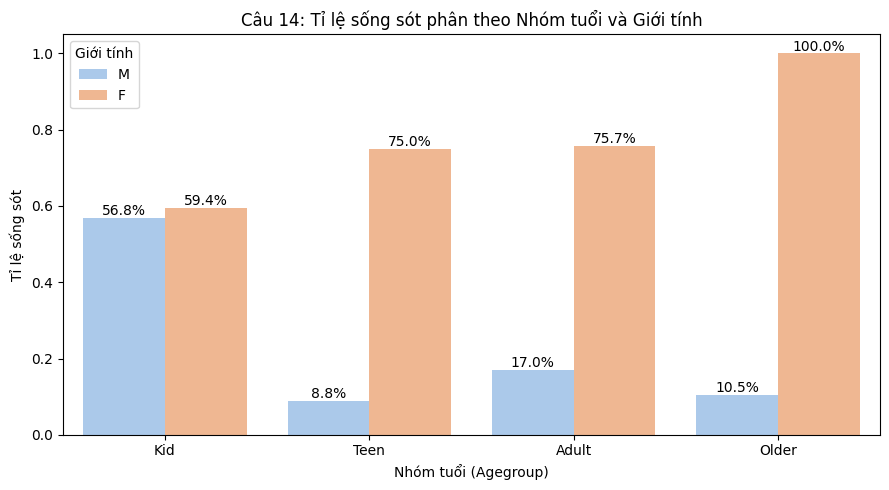

In [113]:
plt.figure(figsize=(9, 5))
# Sử dụng cột Agegroup đã phân loại ở câu 6 để vẽ sự kết hợp xu hướng
ax14 = sns.barplot(x='Agegroup', y='Survived', hue='Sex', data=df, errorbar=None, palette='pastel',
                   order=['Kid', 'Teen', 'Adult', 'Older'])
plt.title('Câu 14: Tỉ lệ sống sót phân theo Nhóm tuổi và Giới tính')
plt.xlabel('Nhóm tuổi (Agegroup)')
plt.ylabel('Tỉ lệ sống sót')
plt.legend(title='Giới tính')
for p in ax14.patches:
    if p.get_height() > 0: # Tránh lỗi đè chữ nếu nhóm đó không có dữ liệu
        ax14.annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

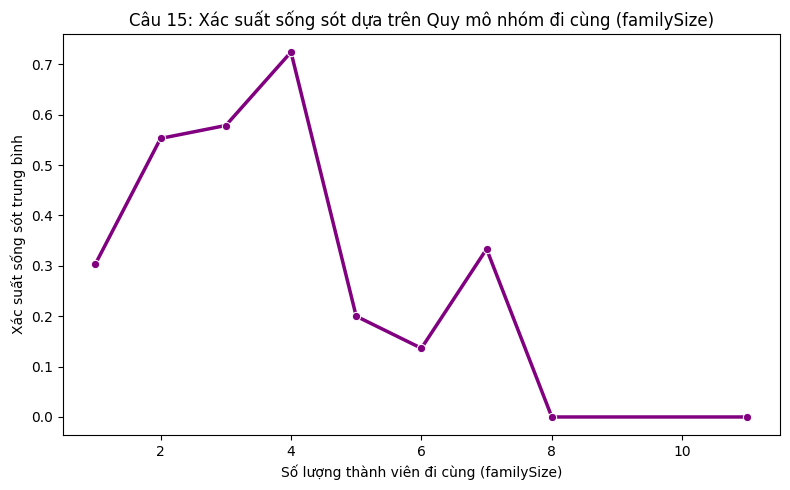

In [114]:
plt.figure(figsize=(8, 5))
# Trực quan mối quan hệ tuyến tính/xu hướng xác suất sống sót theo quy mô gia đình familySize
ax15 = sns.lineplot(x='familySize', y='Survived', data=df, errorbar=None, marker='o', color='purple', linewidth=2.5)
plt.title('Câu 15: Xác suất sống sót dựa trên Quy mô nhóm đi cùng (familySize)')
plt.xlabel('Số lượng thành viên đi cùng (familySize)')
plt.ylabel('Xác suất sống sót trung bình')
plt.tight_layout()
plt.show()

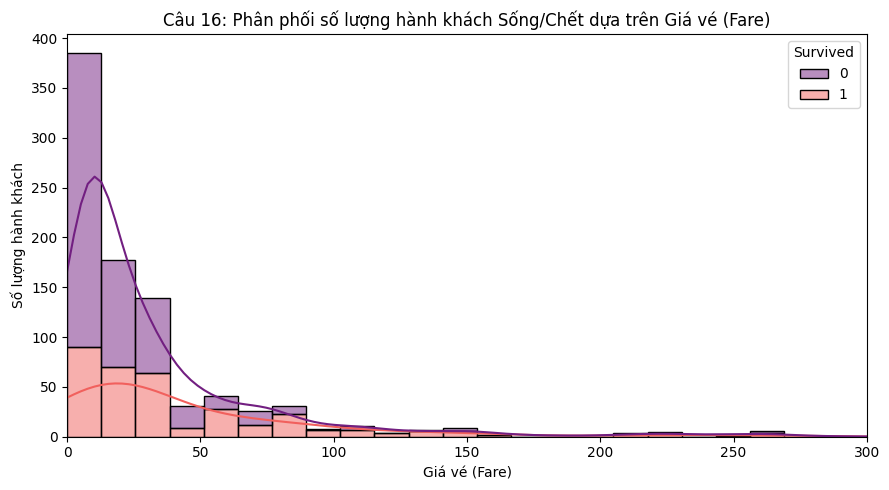

In [115]:
plt.figure(figsize=(9, 5))
# Dùng biểu đồ mật độ phân phối (Histplot hoặc Kdeplot) phân tách theo biến Survived để thấy rõ xu hướng giá vé ảnh hưởng thế nào
sns.histplot(x='Fare', hue='Survived', data=df, kde=True, multiple='stack', palette='magma', bins=40)
plt.title('Câu 16: Phân phối số lượng hành khách Sống/Chết dựa trên Giá vé (Fare)')
plt.xlabel('Giá vé (Fare)')
plt.ylabel('Số lượng hành khách')
plt.xlim(0, 300) # Giới hạn dải vé phổ biến để biểu đồ không bị kéo quá dài do hành khách cá biệt vé siêu cao
plt.tight_layout()
plt.show()

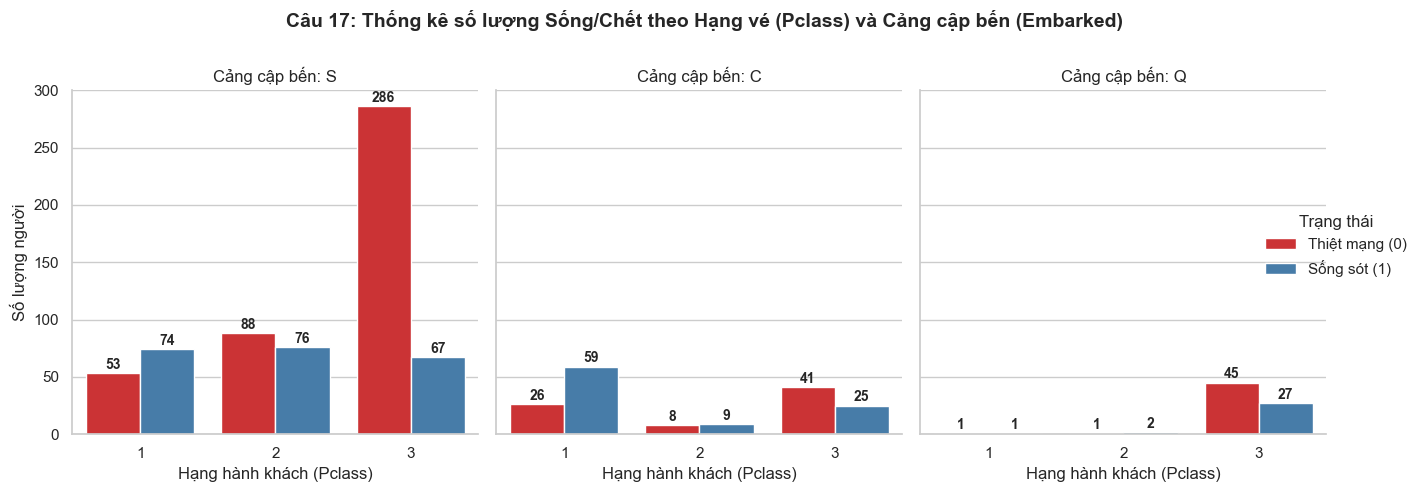

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Giả định dữ liệu df của bạn đã được xử lý xong các câu trước
# df = pd.read_csv('titanic_cleaned_result.csv')

# Thiết lập cấu hình Seaborn để biểu đồ trông sạch sẽ, rõ ràng
sns.set_theme(style="whitegrid")

# Sử dụng sns.catplot để tạo lưới biểu đồ cột (Countplot) dựa theo biến 'Embarked'
g = sns.catplot(
    data=df, 
    x='Pclass', 
    hue='Survived', 
    col='Embarked',
    kind='count', 
    palette='Set1', 
    height=5, 
    aspect=0.9
)

# --- SỬA LỖI TẠI ĐÂY: Thay set_title_headings bằng set_titles ---
g.set_titles("Cảng cập bến: {col_name}")

# Đặt nhãn cho trục hoành và trục tung
g.set_axis_labels("Hạng hành khách (Pclass)", "Số lượng người")

# Cấu hình phần chú thích (Legend)
g._legend.set_title("Trạng thái")
new_labels = ['Thiệt mạng (0)', 'Sống sót (1)']
for t, l in zip(g._legend.texts, new_labels): 
    t.set_text(l)

# Vòng lặp quét qua từng cột biểu đồ nhỏ để vẽ nhãn số lượng lên đầu mỗi cột
for ax in g.axes.flat:
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  # Chỉ hiển thị nếu cột có số lượng lớn hơn 0
            ax.annotate(
                f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', 
                va='center', 
                xytext=(0, 6), 
                textcoords='offset points',
                fontsize=10,
                weight='bold'
            )

# Điều chỉnh khoảng cách phía trên để không bị đè tiêu đề tổng
plt.subplots_adjust(top=0.82)
g.fig.suptitle('Câu 17: Thống kê số lượng Sống/Chết theo Hạng vé (Pclass) và Cảng cập bến (Embarked)', fontsize=14, weight='bold')

# Hiển thị biểu đồ
plt.show()